# PHẦN 1: TẢI DỮ LIỆU VÀ THÊM THƯ VIỆN

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

orders = pd.read_csv('../data/orders.csv')
order_items = pd.read_csv('../data/order_items.csv')
products = pd.read_csv('../data/products.csv')
df_promo = pd.read_csv('../data/promotions.csv')

# PHẦN 2: PHÂN TÍCH TƯƠNG QUAN BIÊN LỢI NHUẬN VÀ FIXED PROMOTION

Trong quá trình đánh giá kinh doanh tổng thể, phân tích chỉ số Biên lợi nhuận (Gross Margin) đã bộc lộ một điểm đáng chú ý: Biên lợi nhuận của toàn hệ thống liên tục xuất hiện các đợt sụt giảm nghiêm trọng, chạm mức âm sâu. Đáng nói, hiện tượng này không diễn ra ngẫu nhiên mà mang tính chu kỳ rõ rệt, lặp lại đều đặn 2 năm một lần.  
Dựa trên quan sát bề mặt, các mốc thời gian biên lợi nhuận rớt xuống mức âm thường trùng khớp với các đợt doanh nghiệp tung ra mã giảm giá cố định (Fixed Promotions). Từ sự tương quan này, giả thuyết ban đầu được đặt ra: Chính các chiến dịch Fixed Promotion là tác nhân làm biên lợi nhuận âm.  


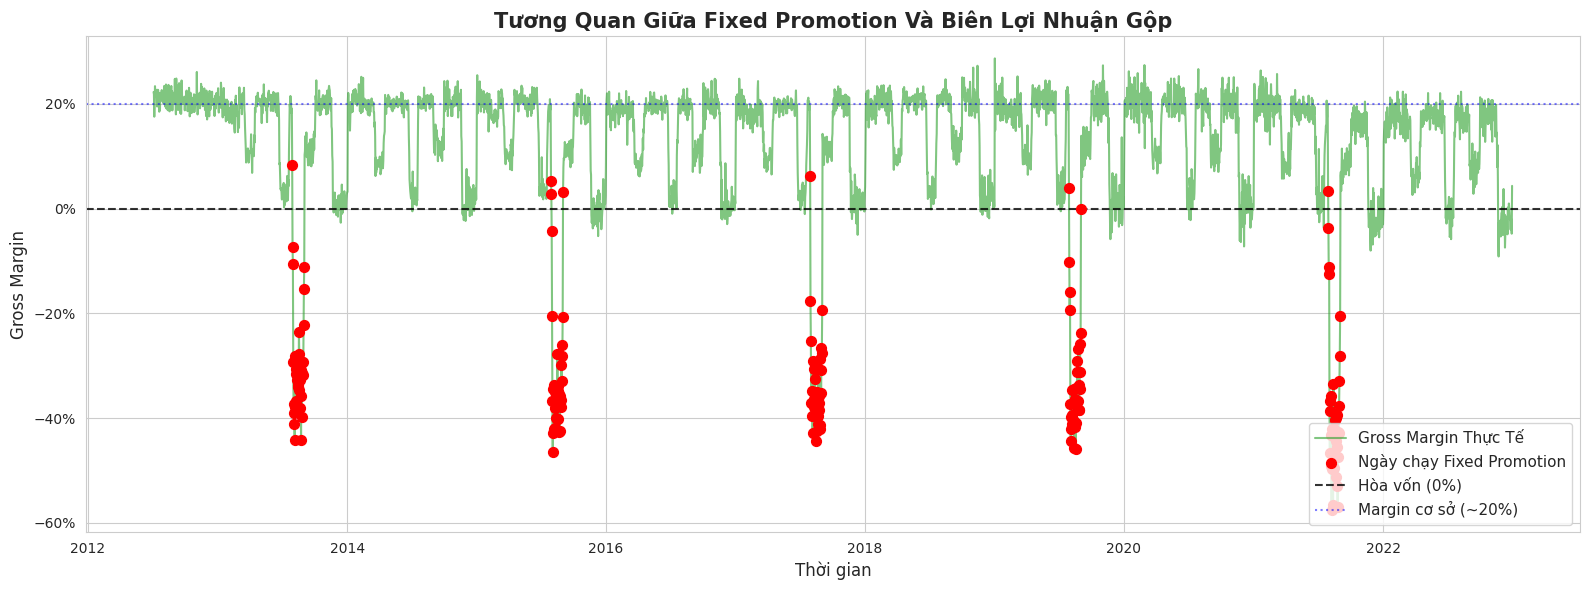

In [4]:
df_margin = order_items.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
df_margin = df_margin.merge(products[['product_id', 'price', 'cogs']], on='product_id', how='left')
df_margin['Date'] = pd.to_datetime(df_margin['order_date']).dt.normalize()

if 'quantity' not in df_margin.columns:
    df_margin['quantity'] = 1
df_margin['Revenue'] = df_margin['unit_price'] * df_margin['quantity']
df_margin['COGS'] = df_margin['cogs'] * df_margin['quantity']

df_sales = df_margin.groupby('Date').agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum')
).reset_index()

df_sales['Actual_Margin'] = (df_sales['Revenue'] - df_sales['COGS']) / df_sales['Revenue']
df_sales['Actual_Margin'] = df_sales['Actual_Margin'].replace([np.inf, -np.inf], np.nan).fillna(0)

df_promo['start_date'] = pd.to_datetime(df_promo['start_date']).dt.normalize()
df_promo['end_date'] = pd.to_datetime(df_promo['end_date']).dt.normalize()
fixed_promos = df_promo[df_promo['promo_type'] == 'fixed'].copy()

def check_if_fixed_promo(current_date):
    active = fixed_promos[(fixed_promos['start_date'] <= current_date) & (fixed_promos['end_date'] >= current_date)]
    return not active.empty

df_sales['is_fixed_promo'] = df_sales['Date'].apply(check_if_fixed_promo)

sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

plt.plot(df_sales['Date'], df_sales['Actual_Margin'], color='#2ca02c', alpha=0.6, label='Gross Margin Thực Tế')

fixed_days = df_sales[df_sales['is_fixed_promo'] == True]
plt.scatter(fixed_days['Date'], fixed_days['Actual_Margin'], color='red', s=50, zorder=5, label='Ngày chạy Fixed Promotion')

plt.axhline(0, color='black', linestyle='--', alpha=0.8, label='Hòa vốn (0%)')
plt.axhline(0.2, color='blue', linestyle=':', alpha=0.5, label='Margin cơ sở (~20%)')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Tương Quan Giữa Fixed Promotion Và Biên Lợi Nhuận Gộp', fontsize=15, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Gross Margin', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

# PHẦN 3: PHÂN TÍCH TỶ LỆ GIÁ THỰC BÁN VỚI GIÁ NIÊM YẾT CỦA SẢN PHẨM

Tuy nhiên, khi phân giải dữ liệu xuống cấp độ giao dịch chi tiết, chúng tôi phát hiện một điểm mâu thuẫn lớn. Mức giảm thực tế của các mã Fixed Promotion này rất nhỏ (chỉ khoảng 50 VNĐ) – một con số hoàn toàn không đáng kể so với giá trị trung bình của một đơn hàng, và chắc chắn không đủ lực để kéo toàn bộ hệ thống chịu lỗ.

Tiếp tục truy xuất lịch sử giá bán của từng sản phẩm, một "biến số ngầm" đã lộ diện: Giá bán (Unit Price) của sản phẩm liên tục biến động và thường xuyên bị đánh sập xuống các mức rất sâu. Sự sụt giảm này hoạt động độc lập, không tuân theo quy luật của bất kỳ chiến dịch khuyến mãi nào đang hiện hữu trên hệ thống.

Từ dữ liệu trên, chúng tôi đi đến kết luận: Tác nhân thực sự không phải là mã khuyến mãi, mà là kịch bản Xả hàng tồn kho (Clearance Sale) từ phía doanh nghiệp. Cụ thể, hệ thống đã can thiệp hạ giá bán thực tế của nhiều sản phẩm xuống thấp hơn cả giá vốn và giá niêm yết. Thời điểm những sản phẩm này "chạm đáy" ăn khớp hoàn hảo với các chu kỳ biên lợi nhuận âm của toàn hệ thống.

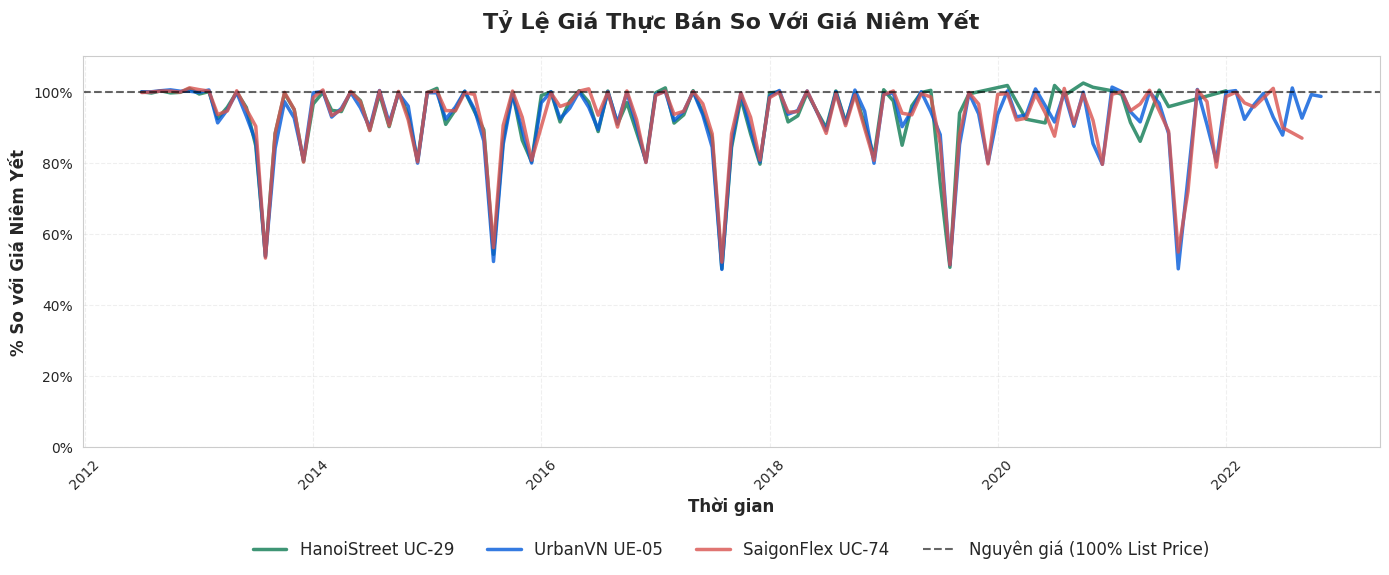

In [5]:
df_ratio = order_items.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
df_ratio = df_ratio.merge(products[['product_id', 'product_name', 'price', 'cogs']], on='product_id', how='left')
df_ratio['order_date'] = pd.to_datetime(df_ratio['order_date'])

products_to_plot = ['HanoiStreet UC-29', 'UrbanVN UE-05', 'SaigonFlex UC-74']
df_filtered = df_ratio[df_ratio['product_name'].isin(products_to_plot)].copy()

df_filtered['price_ratio'] = (df_filtered['unit_price'] / df_filtered['price']) * 100
df_filtered['year_month'] = df_filtered['order_date'].dt.to_period('M')

monthly_ratio = df_filtered.groupby(['year_month', 'product_name'])['price_ratio'].mean().reset_index()
monthly_ratio['date_plot'] = monthly_ratio['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#0f7b53', '#025ada', '#d9534f']

for prod, color in zip(products_to_plot, colors):
    prod_data = monthly_ratio[monthly_ratio['product_name'] == prod].sort_values('date_plot')
    ax.plot(prod_data['date_plot'], prod_data['price_ratio'], color=color, linewidth=2.5, alpha=0.8, label=prod)

ax.axhline(100, color='black', linestyle='--', alpha=0.6, label='Nguyên giá (100% List Price)')

ax.set_title('Tỷ Lệ Giá Thực Bán So Với Giá Niêm Yết', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('% So với Giá Niêm Yết', fontsize=12, fontweight='bold')
ax.set_xlabel('Thời gian', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 110)
ax.grid(axis='both', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

Thay vì âm thầm hạ giá để xả kho và chấp nhận mức biên lợi nhuận âm sâu gây ảnh hưởng đến doanh thu tổng, chúng tôi đề xuất minh bạch hóa chiến lược giá bằng cách chuyển đổi các đợt "giảm giá ngầm" thành các chiến dịch "Khuyến mãi" (Promo) rõ ràng. Việc gắn mác Sale không chỉ tạo hiệu ứng tâm lý kích thích khách hàng mua sắm mạnh hơn giúp đẩy nhanh tốc độ xả hàng, mà còn chiến lược hóa các sản phẩm này thành "Sản phẩm chim mồi" (Loss Leader). Doanh nghiệp hoàn toàn có thể tận dụng lượng truy cập tăng đột biến từ các mặt hàng xả kho để bán chéo (Cross-sell) các sản phẩm có biên lợi nhuận cao, từ đó bù đắp khoản lỗ ban đầu và kéo lại biên lợi nhuận tổng thể